In [2]:
import numpy as np
import ssm

In [61]:
"""Coding a super vanilla HMM"""
# In this example each state is associated to a mesurement of given mean and std with 100% probability

states = [0,1] # what are our states
start_prob = [.9,.1] # probability we start with one state
transition_matrix = [[.8,.2],[.65,.35]] # transition probability between states

obs_mean = np.array([5,-5]) # mean of the measurement
obs_std = np.array([1,1]) # std of the measurement
time = 2500 # time samples

# intiatlize
S = np.zeros((time,),dtype = int)
Obs = np.zeros((time,))

S[0] = np.random.choice(states,p=start_prob)

for t in range(1,time):
    # what are the transition probabilities based on the state at t-1
    trans = transition_matrix[S[t-1]]
    # identify state at time t
    S[t] = np.random.choice(states,p=trans)

# sample the measurements, based on the state
Obs = np.random.normal(loc = obs_mean[S], scale = obs_std[S], size = (time,))

In [9]:
"""Predicting a super vanilla HMM"""
# initialize HMM
this_hmm = ssm.HMM(K = 2, # latent states
                   D = 1, # observation dimension = 1
                   M = 0, # this_inpt.shape[1] there are no inputs
                   observations="gaussian",
                   transitions="standard")

# fit HMM
this_hmm.fit(datas = np.array([[o] for o in Obs]))

# look at parameters
para = this_hmm.params

print('predicted means are: ' + str([this_hmm.observations.mus[0][0],this_hmm.observations.mus[1][0]]) + '\n input means are: ' + str(obs_mean))
print('predicted std are: ' + str([this_hmm.observations._sqrt_Sigmas[0][0][0],this_hmm.observations._sqrt_Sigmas[1][0][0]]) + '\n input std are: ' + str(obs_std))
print('predicted transitions matrix are: ' + str([list(this_hmm.transitions.transition_matrix[0]),list(this_hmm.transitions.transition_matrix[1])]) + '\n input transition matrix are: ' + str(transition_matrix))

  0%|          | 0/100 [00:00<?, ?it/s]

predicted means are: [-4.963196715209245, 5.001661465491121]
 input means are: [ 5 -5]
predicted std are: [2.980306382327532, 0.9945893491539645]
 input std are: [1 3]


NameError: name 'transition_matrix' is not defined

In [24]:
"""Coding a vanilla HMM with long states"""
time = 25000 # time samples
mean = 200*60*1 # (Hz*s*n_min)
std = 40*10
# create initial segment
start_prob = [.65,.35]
states = [0,1] # what are our states
s = np.random.choice(states,p=start_prob)
if s == 1:
    S = np.append(s,np.ones(int(np.random.normal(loc = mean, scale = std))))
if s == 0:
    S = np.append(s,np.zeros(int(np.random.normal(loc = mean, scale = std))))
# create full sequence
while len(S) < time:
    if S[-1] == 0:
        S = np.append(S,np.ones(int(np.random.normal(loc = mean, scale = std))))
    if S[-1] == 1:
        S = np.append(S,np.zeros(int(np.random.normal(loc = mean, scale = std))))
# ensure appropriate length
S = S[:time]

obs_mean = np.array([5,-5]) # mean of the measurement
obs_std = np.array([1,3]) # std of the measurement
Obs = np.random.normal(loc = obs_mean[S.astype(int)], scale = obs_std[S.astype(int)], size = (time,))

  0%|          | 0/100 [00:00<?, ?it/s]

predicted means are: [-5.00531329903459, 5.05830695052263]
 input means are: [ 5 -5]
predicted std are: [3.0105914676389105, 0.9726843240995541]
 input std are: [1 3]


ValueError: zero-size array to reduction operation maximum which has no identity

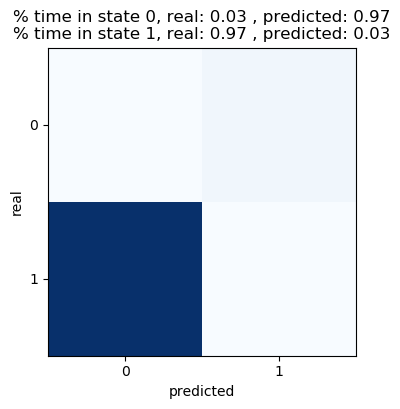

In [18]:
"""Predicting a vanilla HMM with long states"""
# initialize HMM
this_hmm = ssm.HMM(K = 2, # latent states
                   D = 1, # observation dimension = 1
                   M = 0, # this_inpt.shape[1] there are no inputs
                   observations="gaussian",
                   transitions="standard")

# fit HMM
this_hmm.fit(datas = np.array([[o] for o in Obs]), tolerance=10**-4)

# look at parameters
para = this_hmm.params

print('predicted means are: ' + str([this_hmm.observations.mus[0][0],this_hmm.observations.mus[1][0]]) + '\n input means are: ' + str(obs_mean))
print('predicted std are: ' + str([this_hmm.observations._sqrt_Sigmas[0][0][0],this_hmm.observations._sqrt_Sigmas[1][0][0]]) + '\n input std are: ' + str(obs_std))

"""How well did it guess the state at each time?"""
state_pred = this_hmm.most_likely_states(np.array([[o] for o in Obs]))

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
conf = confusion_matrix(S, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(S == 0)/len(S)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(S == 1)/len(S)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))

"""How long does each state bout last?"""

if S[0] == 1:
    completeS = 
start = np.where(np.diff(S) == 1)[0]
end = np.where(np.diff(S) == -1)[0]
real_time = np.abs(start - end)

start = np.where(np.diff(state_pred) == 1)[0]
end = np.where(np.diff(state_pred) == -1)[0]
if len(start) > len(end):
    start = start[:len(end)]
if len(start) < len(end):
    end = end[:len(start)]
pred_time = np.abs(start - end)

longest = np.amax(np.append(pred_time, real_time))
shortest = np.amin(np.append(pred_time, real_time))

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.hist(real_time, range = [shortest,longest], density = True, alpha = .5)
axs.hist(pred_time, range = [shortest,longest], density = True, alpha = .5)
axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')
axs.legend(['real','predicted'])

"""Distribution of values in the two states"""
pred_latents, pred_angles = this_hmm.sample(len(Obs))

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].hist(Obs[S == 0], alpha = .5, color = ['cornflowerblue'])
axs[0].hist(Obs[S == 1], alpha = .5, color = ['darkorchid'])
axs[0].set_title('Dist. true angles in true states')
axs[0].set_xlabel('binned angles')

axs[1].hist(pred_angles[pred_latents == 0], alpha = .5, color = ['cornflowerblue'])
axs[1].hist(pred_angles[pred_latents == 1], alpha = .5, color = ['darkorchid'])
axs[1].set_title('Dist. pred angles in pred states')
axs[1].set_xlabel('binned angles')

In [59]:
"""Coding a vanilla HMM with chocolate chips"""
# here each state is associated with a probability vector of associations with different measurements

states = [0,1] # what are our states
start_prob = [.9,.1] # probability we start with one state
transition_matrix = [[.8,.2],[.65,.35]] # transition probability between states

obs_mean = np.arange(4) # the observation values
obs_prob = [np.random.rand(4),np.random.rand(4)] # the probability vectors that each state will lead to the observations
obs_prob = [x/np.sum(x) for x in obs_prob]
time = 25 # time samples

# intiatlize
S = np.zeros((time,),dtype = int)
Obs = np.zeros((time,))

S[0] = np.random.choice(states,p=start_prob)
Obs[0] = np.random.choice(obs_mean,p=obs_prob[S[t]])

for t in range(1,time):
    # what are the transition probabilities based on the state at t-1
    trans = transition_matrix[S[t-1]]
    # identify state at time t
    S[t] = np.random.choice(states,p=trans)
    # given our state select an observation, based on input/output probs
    Obs[t] = np.random.choice(obs_mean,p=obs_prob[S[t]])

print(S)
print(Obs)

[0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
[1. 0. 1. 3. 3. 2. 1. 2. 3. 2. 0. 0. 0. 1. 0. 3. 1. 1. 2. 2. 2. 3. 1. 1.
 0.]


In [191]:
"""Coding a (G)LM-HMM"""
states = [0,1] # what are our states
start_prob = [.9,.1] # probability we start with one state
transition_matrix = [[.8,.2],[.65,.35]] # transition probability between states

neurons = 10
time = 2500
n_fr = np.random.randint(1,25,size = (neurons)) # firing rate of each neuron
std_fr = np.random.rand(neurons) # std of each neuron's fr
predictors = np.array([np.random.normal(loc = fr, scale = std, size = time) for (std,fr) in zip(std_fr,n_fr)]).T # t*n
w = [np.random.random(neurons),np.random.random(neurons)] # weights of neurons in each state

# intiatlize
S = np.zeros((time,),dtype = int)
Obs = np.zeros((time,))

S[0] = np.random.choice(states,p=start_prob)
weight = w[S[0]]
Obs[0] = np.matmul(predictors[0,:],weight)

for t in range(1,time):
    # what are the transition probabilities based on the state at t-1
    trans = transition_matrix[S[t-1]]
    # identify state at time t
    S[t] = np.random.choice(states,p=trans)
    # given our state what is the weight_vector
    weight = w[S[t]]
    Obs[t] = np.matmul(predictors[t,:],weight)

In [205]:
predictors

array([[20.47785678,  9.87250999,  8.14951752, ..., 13.00567735,
         2.08509477, 15.99588123],
       [21.93221166, 10.36803956,  8.25786419, ..., 13.07789832,
         1.88855168, 15.922048  ],
       [22.04454354,  9.83072192,  7.7821414 , ..., 13.02936152,
         3.58489426, 16.27627202],
       ...,
       [19.58404243,  9.0523467 ,  8.03357519, ..., 12.95300989,
         1.91127558, 15.91690571],
       [18.92877619, 10.03835257,  7.79147586, ..., 13.00057136,
         1.91160375, 16.05186403],
       [19.62890809, 10.20703274,  8.17960116, ..., 13.03415312,
         1.359841  , 15.87194366]])

In [203]:
"""Predicting a (G)LM-HMM"""
# initialize HMM
this_hmm = ssm.HMM(K = 2, # latent states
                   D = 1, # observation dimension = 1
                   M = neurons, # input.shape[1] 
                   observations="input_driven_obs",
                   observation_kwargs=dict(C=100), # C needs to be greater than the biggest value in datas?! Probably need to normalize datas
                   transitions="standard")

# fit HMM
this_hmm.fit(datas = [np.array([[o] for o in Obs])],inputs = [predictors], method="em", num_iters=100, tolerance=10**-4)

# # look at parameters
# para = this_hmm.params

# print('predicted means are: ' + str([this_hmm.observations.mus[0][0],this_hmm.observations.mus[1][0]]) + '\n input means are: ' + str(obs_mean))
# print('predicted std are: ' + str([this_hmm.observations._sqrt_Sigmas[0][0][0],this_hmm.observations._sqrt_Sigmas[1][0][0]]) + '\n input std are: ' + str(obs_std))
# print('predicted transitions matrix are: ' + str([list(this_hmm.transitions.transition_matrix[0]),list(this_hmm.transitions.transition_matrix[1])]) + '\n input transition matrix are: ' + str(transition_matrix))

AssertionError: 

In [202]:
def one_hot(z, K):
    z = np.atleast_1d(z).astype(int)
    assert np.all(z >= 0) and np.all(z < K)
    shp = z.shape
    N = z.size
    zoh = np.zeros((N, K))
    zoh[np.arange(N), np.arange(K)[np.ravel(z)]] = 1
    zoh = np.reshape(zoh, shp + (K,))
    return zoh

datas = [np.array([[o] for o in Obs])]
for data in datas:
    data_one_hot = one_hot(data[:, 0], 100)

In [201]:
z = np.atleast_1d(data[:, 0]).astype(int)
data[:, 0]

array([64.1175719 , 59.37683659, 59.82738809, ..., 61.13875481,
       56.64504544, 57.26495351])

In [185]:
# Set the parameters of the GLM-HMM
num_states = 3        # number of discrete states
obs_dim = 1           # number of observed dimensions
# num_categories = 2    # number of categories for output
input_dim = 2         # input dimensions

# Make a GLM-HMM
true_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", transitions="standard")

num_sess = 1 # number of example sessions
num_trials_per_sess = 100 # number of trials in a session
inpts = np.ones((num_sess, num_trials_per_sess, input_dim)) # initialize inpts array
stim_vals = [-1, -0.5, -0.25, -0.125, -0.0625, 0, 0.0625, 0.125, 0.25, 0.5, 1]
inpts[:,:,0] = np.random.choice(stim_vals, (num_sess, num_trials_per_sess)) # generate random sequence of stimuli
inpts = list(inpts) #convert inpts to correct format

# Generate a sequence of latents and choices for each session
true_latents, true_choices = [], []
for sess in range(num_sess):
    true_z, true_y = true_glmhmm.sample(num_trials_per_sess, input=inpts[sess])
    true_latents.append(true_z)
    true_choices.append(true_y)

new_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", transitions="standard")

N_iters = 100 # maximum number of EM iterations. Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
fit_ll = new_glmhmm.fit(true_choices, inputs=inpts, method="em", num_iters=N_iters, tolerance=10**-4)

  0%|          | 0/100 [00:00<?, ?it/s]